In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scorecardpy as sc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)



In [2]:
# Load all 3 files
app    = pd.read_csv('../Data/application_train.csv')
bureau = pd.read_csv('../Data/bureau.csv')
prev   = pd.read_csv('../Data/previous_application.csv')

print("Data loaded ✓")
print(f"App shape    : {app.shape}")
print(f"Bureau shape : {bureau.shape}")
print(f"Prev shape   : {prev.shape}")

Data loaded ✓
App shape    : (307511, 122)
Bureau shape : (1716428, 17)
Prev shape   : (1670214, 37)


In [3]:
# clean known anomalies 
# Fix DAYS_EMPLOYED anomaly (365243 = unemployed/retired)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)

# Convert days to years (more interpretable)
app['AGE_YEARS']         = abs(app['DAYS_BIRTH'])        / 365
app['EMPLOYMENT_YEARS']  = abs(app['DAYS_EMPLOYED'])     / 365
app['ID_PUBLISH_YEARS']  = abs(app['DAYS_ID_PUBLISH'])   / 365
app['REGISTRATION_YEARS']= abs(app['DAYS_REGISTRATION']) / 365

# Drop original days columns (we have years versions now)
days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 
             'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION']
app.drop(columns=days_cols, inplace=True)

print("Anomalies fixed ✓")
print(f"Shape after cleaning: {app.shape}")

Anomalies fixed ✓
Shape after cleaning: (307511, 122)


In [4]:
# Engineer ratio features from main table
# These are features EDA told us matter more than raw values

# Loan ratios
app['CREDIT_INCOME_RATIO']    = app['AMT_CREDIT']  / app['AMT_INCOME_TOTAL']
app['ANNUITY_INCOME_RATIO']   = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
app['CREDIT_TERM']            = app['AMT_ANNUITY'] / app['AMT_CREDIT']
app['GOODS_CREDIT_RATIO']     = app['AMT_GOODS_PRICE'] / app['AMT_CREDIT']

# EXT_SOURCE combined features (from our EDA insight)
app['EXT_SOURCE_MEAN'] = app[['EXT_SOURCE_1',
                               'EXT_SOURCE_2',
                               'EXT_SOURCE_3']].mean(axis=1)

app['EXT_SOURCE_MIN']  = app[['EXT_SOURCE_1',
                               'EXT_SOURCE_2',
                               'EXT_SOURCE_3']].min(axis=1)

app['EXT_SOURCE_STD']  = app[['EXT_SOURCE_1',
                               'EXT_SOURCE_2',
                               'EXT_SOURCE_3']].std(axis=1)

# Age x Employment interaction
# Younger + shorter employment = riskier combination
app['AGE_EMPLOYMENT_RATIO'] = app['EMPLOYMENT_YEARS'] / app['AGE_YEARS']

# Document submission score
# How many documents did the applicant submit? (flag columns)
doc_cols = [col for col in app.columns if 'FLAG_DOCUMENT' in col]
app['DOCUMENTS_SUBMITTED'] = app[doc_cols].sum(axis=1)

# Social circle risk
# Do people around the applicant default?
app['SOCIAL_CIRCLE_DEFAULT'] = (app['DEF_30_CNT_SOCIAL_CIRCLE'] + 
                                 app['DEF_60_CNT_SOCIAL_CIRCLE'])

print(f"New features engineered ✓")
print(f"Shape after engineering: {app.shape}")

# Quick check — do new features correlate with target?
new_features = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
                'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN',
                'AGE_EMPLOYMENT_RATIO', 'CREDIT_TERM']

print("\nNew feature correlations with TARGET:")
for f in new_features:
    corr = app[f].corr(app['TARGET'])
    print(f"  {f:30s}: {corr:.4f}")

New features engineered ✓
Shape after engineering: (307511, 132)

New feature correlations with TARGET:
  CREDIT_INCOME_RATIO           : -0.0077
  ANNUITY_INCOME_RATIO          : 0.0143
  EXT_SOURCE_MEAN               : -0.2221
  EXT_SOURCE_MIN                : -0.1853
  AGE_EMPLOYMENT_RATIO          : -0.0680
  CREDIT_TERM                   : 0.0127


In [5]:
# Aggregate Bureau table 
# One applicant has multiple bureau rows
# We need ONE row per applicant — so we aggregate

# Numerical aggregations
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT        = ('SK_ID_BUREAU',    'count'),
    BUREAU_ACTIVE_LOANS      = ('CREDIT_ACTIVE',   lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_LOANS      = ('CREDIT_ACTIVE',   lambda x: (x == 'Closed').sum()),
    BUREAU_AVG_CREDIT_AMT    = ('AMT_CREDIT_SUM',  'mean'),
    BUREAU_MAX_CREDIT_AMT    = ('AMT_CREDIT_SUM',  'max'),
    BUREAU_TOTAL_DEBT        = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_AVG_OVERDUE       = ('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    BUREAU_MAX_OVERDUE_DAYS  = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_AVG_OVERDUE_DAYS  = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_PROLONGED_COUNT   = ('CNT_CREDIT_PROLONG', 'sum'),
).reset_index()

# Ratio of active to total loans
bureau_agg['BUREAU_ACTIVE_RATIO'] = (bureau_agg['BUREAU_ACTIVE_LOANS'] / 
                                      bureau_agg['BUREAU_LOAN_COUNT'])

print(f"Bureau aggregated ✓")
print(f"Shape: {bureau_agg.shape}")
print(f"\nColumns created:")
print(bureau_agg.columns.tolist())

Bureau aggregated ✓
Shape: (305811, 12)

Columns created:
['SK_ID_CURR', 'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_CLOSED_LOANS', 'BUREAU_AVG_CREDIT_AMT', 'BUREAU_MAX_CREDIT_AMT', 'BUREAU_TOTAL_DEBT', 'BUREAU_AVG_OVERDUE', 'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_AVG_OVERDUE_DAYS', 'BUREAU_PROLONGED_COUNT', 'BUREAU_ACTIVE_RATIO']


In [6]:
# Aggregate previous application table 
# Same idea — one applicant has multiple previous applications
# Aggregate to one row per applicant

prev_agg = prev.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT           = ('SK_ID_PREV',       'count'),
    PREV_APPROVED_COUNT      = ('NAME_CONTRACT_STATUS', 
                                lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT       = ('NAME_CONTRACT_STATUS', 
                                lambda x: (x == 'Refused').sum()),
    PREV_AVG_CREDIT          = ('AMT_CREDIT',        'mean'),
    PREV_MAX_CREDIT          = ('AMT_CREDIT',        'max'),
    PREV_AVG_ANNUITY         = ('AMT_ANNUITY',       'mean'),
    PREV_AVG_DOWN_PAYMENT    = ('AMT_DOWN_PAYMENT',  'mean'),
    PREV_LAST_STATUS         = ('NAME_CONTRACT_STATUS', 'last'),
).reset_index()

# Approval rate from previous applications
prev_agg['PREV_APPROVAL_RATE'] = (prev_agg['PREV_APPROVED_COUNT'] / 
                                   prev_agg['PREV_APP_COUNT'])

print(f"Previous apps aggregated ✓")
print(f"Shape: {prev_agg.shape}")

Previous apps aggregated ✓
Shape: (338857, 10)


In [7]:
# Merge everything into one master table 
# Start with main application table
master = app.copy()

# Left join bureau aggregations
master = master.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Left join previous application aggregations
master = master.merge(prev_agg, on='SK_ID_CURR', how='left')

print(f"Master table created ✓")
print(f"Shape: {master.shape}")

# How many applicants had no bureau history?
no_bureau = master['BUREAU_LOAN_COUNT'].isna().sum()
print(f"\nApplicants with no bureau history : {no_bureau:,} ({no_bureau/len(master)*100:.1f}%)")

# How many had no previous applications?
no_prev = master['PREV_APP_COUNT'].isna().sum()
print(f"Applicants with no previous apps  : {no_prev:,} ({no_prev/len(master)*100:.1f}%)")

Master table created ✓
Shape: (307511, 152)

Applicants with no bureau history : 44,020 (14.3%)
Applicants with no previous apps  : 16,454 (5.4%)


In [8]:
# Fill missing values
# Count columns — NaN means zero history, fill with 0
count_cols = ['BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 
              'BUREAU_CLOSED_LOANS', 'PREV_APP_COUNT',
              'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT',
              'BUREAU_PROLONGED_COUNT', 'DOCUMENTS_SUBMITTED']

master[count_cols] = master[count_cols].fillna(0)

# Ratio/amount columns — fill with median
ratio_cols = ['BUREAU_ACTIVE_RATIO', 'PREV_APPROVAL_RATE',
              'BUREAU_AVG_OVERDUE', 'BUREAU_MAX_OVERDUE_DAYS']

for col in ratio_cols:
    master[col] = master[col].fillna(master[col].median())

# EXT_SOURCE — fill with median (they have ~20-30% missing)
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    master[col] = master[col].fillna(master[col].median())

# Recalculate combined EXT features after filling
master['EXT_SOURCE_MEAN'] = master[['EXT_SOURCE_1',
                                     'EXT_SOURCE_2',
                                     'EXT_SOURCE_3']].mean(axis=1)
master['EXT_SOURCE_MIN']  = master[['EXT_SOURCE_1',
                                     'EXT_SOURCE_2',
                                     'EXT_SOURCE_3']].min(axis=1)

print("Missing values handled ✓")
print(f"\nRemaining missing values (top 10):")
missing = master.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(10))

Missing values handled ✓

Remaining missing values (top 10):
COMMONAREA_AVG              214865
COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
dtype: int64


In [10]:
# Get full missing value picture
missing_full = pd.DataFrame({
    'Missing Count': master.isnull().sum(),
    'Missing %': (master.isnull().sum() / len(master) * 100).round(2)
})

missing_full = missing_full[missing_full['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"Total columns with missing values: {len(missing_full)}")
print("\nFull missing value report:")
print(missing_full)

Total columns with missing values: 80

Full missing value report:
                          Missing Count  Missing %
COMMONAREA_AVG                   214865      69.87
COMMONAREA_MEDI                  214865      69.87
COMMONAREA_MODE                  214865      69.87
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
...                                 ...        ...
CREDIT_TERM                          12       0.00
ANNUITY_INCOME_RATIO                 12       0.00
DAYS_LAST_PHONE_CHANGE                1       0.00
CNT_FAM_MEMBERS                       2       0.00
AMT_ANNUITY                          12       0.00

[80 rows x 2 columns]


In [10]:
# Step 1 — Drop columns with more than 60% missing
threshold = 60
high_missing_cols = missing_full[missing_full['Missing %'] > threshold].index.tolist()

print(f"Columns with >60% missing (dropping): {len(high_missing_cols)}")
print(high_missing_cols)

master.drop(columns=high_missing_cols, inplace=True)
print(f"\nShape after dropping: {master.shape}")

# Step 2 — For remaining missing columns (30-60% missing)
# Fill with median + add binary flag column
still_missing = master.columns[master.isnull().any()].tolist()

# Remove TARGET and ID from this list
still_missing = [c for c in still_missing 
                 if c not in ['TARGET', 'SK_ID_CURR']]

print(f"\nColumns still missing after drop: {len(still_missing)}")

for col in still_missing:
    missing_pct = master[col].isnull().mean() * 100
    
    if missing_pct > 30:
        # Add a flag column — missing itself might be informative
        master[f'{col}_MISSING'] = master[col].isnull().astype(int)
    
    # Fill with median for numerical, mode for categorical
    if master[col].dtype == 'object':
        master[col] = master[col].fillna(master[col].mode()[0])
    else:
        master[col] = master[col].fillna(master[col].median())

# Final check
remaining_missing = master.isnull().sum().sum()
print(f"\nTotal missing values remaining: {remaining_missing}")
print("Missing values fully handled ✓")

Columns with >60% missing (dropping): 17
['COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE']

Shape after dropping: (307511, 135)

Columns still missing after drop: 63

Total missing values remaining: 0
Missing values fully handled ✓


In [11]:
print(f"Final master shape : {master.shape}")
print(f"Missing values     : {master.isnull().sum().sum()}")
print(f"Target distribution:\n{master['TARGET'].value_counts()}")

Final master shape : (307511, 152)
Missing values     : 9342663
Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [12]:
# sc.iv() is too slow on 167 columns
# We manually select the most meaningful columns based on EDA
# This is actually better practice — domain-driven feature selection

woe_cols = [
    'TARGET',
    # EXT SOURCE — strongest predictors from EDA
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN',
    
    # Applicant demographics
    'AGE_YEARS', 'EMPLOYMENT_YEARS', 'AGE_EMPLOYMENT_RATIO',
    'CODE_GENDER', 'NAME_EDUCATION_TYPE',
    'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS',
    
    # Loan features
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
    
    # Bureau features
    'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_RATIO',
    'BUREAU_AVG_OVERDUE', 'BUREAU_MAX_OVERDUE_DAYS',
    'BUREAU_TOTAL_DEBT',
    
    # Previous application features
    'PREV_APP_COUNT', 'PREV_APPROVAL_RATE', 'PREV_REFUSED_COUNT',
    
    # Other
    'DOCUMENTS_SUBMITTED', 'REGION_RATING_CLIENT'
]

# Filter to only columns that exist in master
woe_cols = [c for c in woe_cols if c in master.columns]

woe_data = master[woe_cols].copy()

print(f"Running WoE/IV on {len(woe_cols)} selected columns ✓")
print(f"Shape: {woe_data.shape}")



Running WoE/IV on 29 selected columns ✓
Shape: (307511, 29)


In [15]:

iv_results = sc.iv(woe_data, y='TARGET')

print("IV Calculation complete ✓")
print("\n=== INFORMATION VALUE RESULTS ===")
print(iv_results.sort_values('info_value', ascending=False).to_string())

IV Calculation complete ✓

=== INFORMATION VALUE RESULTS ===
                   variable  info_value
4            EXT_SOURCE_MIN    1.286340
3               CREDIT_TERM    1.099250
26      CREDIT_INCOME_RATIO    1.061424
5              EXT_SOURCE_1    0.971505
8      ANNUITY_INCOME_RATIO    0.970520
16        BUREAU_TOTAL_DEBT    0.868207
0               AMT_ANNUITY    0.658588
19             EXT_SOURCE_2    0.487980
12     AGE_EMPLOYMENT_RATIO    0.452694
15         EMPLOYMENT_YEARS    0.445659
10                AGE_YEARS    0.414491
14               AMT_CREDIT    0.399155
20             EXT_SOURCE_3    0.383356
11         AMT_INCOME_TOTAL    0.163207
9        BUREAU_AVG_OVERDUE    0.131683
6       BUREAU_ACTIVE_RATIO    0.115086
7        PREV_APPROVAL_RATE    0.085966
25  BUREAU_MAX_OVERDUE_DAYS    0.068592
13         NAME_INCOME_TYPE    0.058336
17       PREV_REFUSED_COUNT    0.057801
2       NAME_EDUCATION_TYPE    0.050836
27     REGION_RATING_CLIENT    0.048317
22              COD

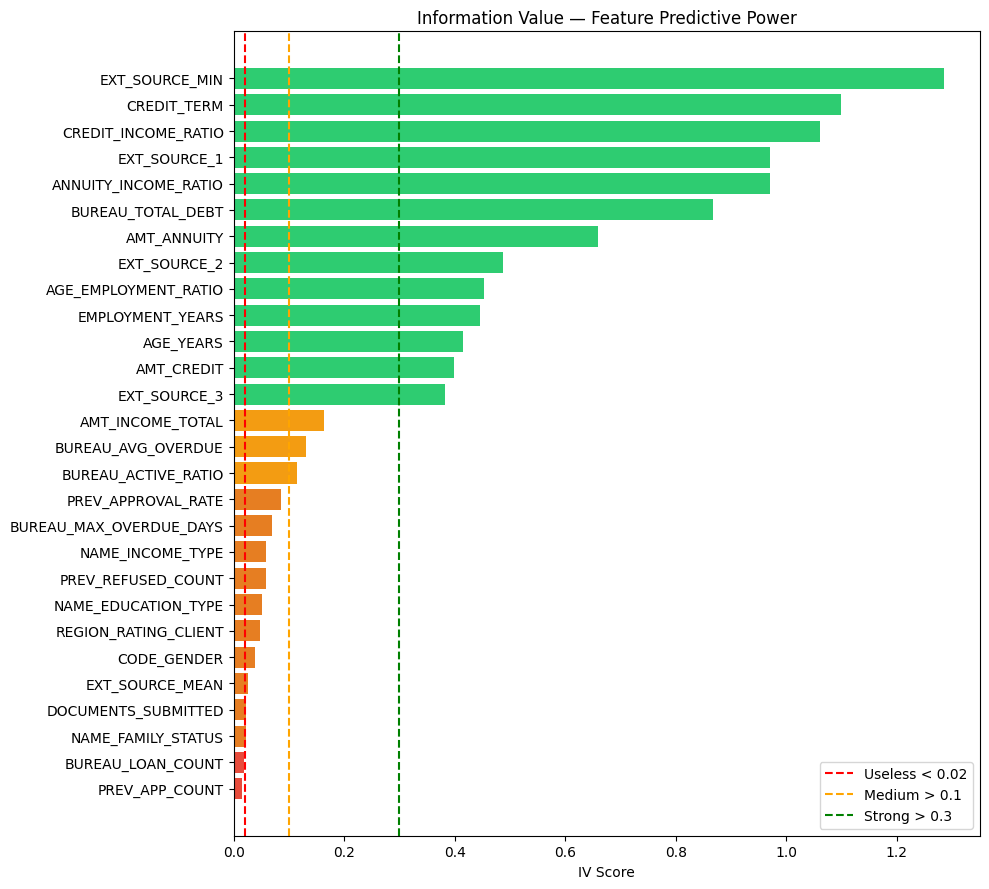

In [16]:
#Visualize the IV results
plt.figure(figsize=(10, 9))

colors = ['#2ecc71' if v > 0.3 
          else '#f39c12' if v > 0.1 
          else '#e67e22' if v > 0.02 
          else '#e74c3c' 
          for v in iv_results.sort_values('info_value')['info_value']]

plt.barh(iv_results.sort_values('info_value')['variable'],
         iv_results.sort_values('info_value')['info_value'],
         color=colors)

plt.axvline(x=0.02, color='red',    linestyle='--', label='Useless < 0.02')
plt.axvline(x=0.1,  color='orange', linestyle='--', label='Medium > 0.1')
plt.axvline(x=0.3,  color='green',  linestyle='--', label='Strong > 0.3')
plt.title('Information Value — Feature Predictive Power')
plt.xlabel('IV Score')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Drop useless features (IV < 0.02)
drop_features = iv_results[iv_results['info_value'] < 0.02]['variable'].tolist()
print(f"Dropping {len(drop_features)} useless features: {drop_features}")

# Keep everything above 0.02
good_features = iv_results[iv_results['info_value'] >= 0.02]['variable'].tolist()
print(f"Keeping {len(good_features)} features")

# Build final dataset
final_cols = good_features + ['TARGET', 'SK_ID_CURR']
final_cols = [c for c in final_cols if c in master.columns]

master_final = master[final_cols].copy()

# Save to data folder
master_final.to_csv('../data/master_features.csv', index=False)

print(f"\nFinal shape       : {master_final.shape}")
print(f"master_features.csv saved ✓")

Dropping 2 useless features: ['BUREAU_LOAN_COUNT', 'PREV_APP_COUNT']
Keeping 26 features

Final shape       : (307511, 28)
master_features.csv saved ✓


In [19]:
# Check multicollinearity — keep higher IV feature from correlated pairs

num_features = master_final.select_dtypes(
    include=['float64', 'int64']).columns.tolist()
num_features = [c for c in num_features 
                if c not in ['TARGET', 'SK_ID_CURR']]

corr_matrix = master_final[num_features].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Build IV lookup from iv_results
iv_lookup = dict(zip(iv_results['variable'], iv_results['info_value']))

cols_to_drop = set()

for col in upper.columns:
    correlated_with = upper.index[upper[col] > 0.85].tolist()
    
    for corr_col in correlated_with:
        # Keep the one with higher IV, drop the other
        iv_col      = iv_lookup.get(col, 0)
        iv_corr_col = iv_lookup.get(corr_col, 0)
        
        drop_this = col if iv_col < iv_corr_col else corr_col
        cols_to_drop.add(drop_this)
        
        print(f"Correlated pair: {col} (IV={iv_col:.3f}) "
              f"vs {corr_col} (IV={iv_corr_col:.3f}) "
              f"→ dropping {drop_this}")

print(f"\nColumns to drop: {list(cols_to_drop)}")
master_final.drop(columns=list(cols_to_drop), inplace=True)

# Save updated version
master_final.to_csv('../data/master_features.csv', index=False)

print(f"\nFinal shape after correlation filter: {master_final.shape}")
print("master_features.csv updated ✓")


Columns to drop: []

Final shape after correlation filter: (307511, 26)
master_features.csv updated ✓


In [20]:
print("""
=== PHASE 3 COMPLETE ===

ENGINEERED FEATURES:
  Ratio based    → CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_TERM
  EXT combined   → EXT_SOURCE_MEAN, EXT_SOURCE_MIN, EXT_SOURCE_STD
  Age/Employment → AGE_YEARS, EMPLOYMENT_YEARS, AGE_EMPLOYMENT_RATIO
  Bureau         → BUREAU_TOTAL_DEBT, BUREAU_AVG_OVERDUE, BUREAU_ACTIVE_RATIO
  Previous apps  → PREV_APPROVAL_RATE, PREV_REFUSED_COUNT

TOP PREDICTORS FOUND (IV > 0.3):
  1. EXT_SOURCE_MIN       → 1.29 (strongest single feature)
  2. CREDIT_TERM          → 1.10
  3. CREDIT_INCOME_RATIO  → 1.06
  4. EXT_SOURCE_1         → 0.97
  5. ANNUITY_INCOME_RATIO → 0.97

DROPPED (IV < 0.02):
  BUREAU_LOAN_COUNT, PREV_APP_COUNT

OUTPUT:
  master_features.csv → ready for Phase 4 modeling
""")


=== PHASE 3 COMPLETE ===

ENGINEERED FEATURES:
  Ratio based    → CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_TERM
  EXT combined   → EXT_SOURCE_MEAN, EXT_SOURCE_MIN, EXT_SOURCE_STD
  Age/Employment → AGE_YEARS, EMPLOYMENT_YEARS, AGE_EMPLOYMENT_RATIO
  Bureau         → BUREAU_TOTAL_DEBT, BUREAU_AVG_OVERDUE, BUREAU_ACTIVE_RATIO
  Previous apps  → PREV_APPROVAL_RATE, PREV_REFUSED_COUNT

TOP PREDICTORS FOUND (IV > 0.3):
  1. EXT_SOURCE_MIN       → 1.29 (strongest single feature)
  2. CREDIT_TERM          → 1.10
  3. CREDIT_INCOME_RATIO  → 1.06
  4. EXT_SOURCE_1         → 0.97
  5. ANNUITY_INCOME_RATIO → 0.97

DROPPED (IV < 0.02):
  BUREAU_LOAN_COUNT, PREV_APP_COUNT

OUTPUT:
  master_features.csv → ready for Phase 4 modeling

